In [199]:
import geopandas as gpd
import pandas as pd
import gpxpy
import glob
import gpxpy.gpx
from shapely.geometry import LineString
import matplotlib.pyplot as plt
from shapely.geometry import Point
import contextily as ctx
import matplotlib.animation as animation
import numpy as np
from utils import *
import osmnx as ox
    

In [ ]:
%matplotlib widget
#%matplotlib inline

In [214]:

list_districts = ["Barcelona", "Ciutat Vella", "Eixample", "Sants–Montjuic", "Les Corts", "Sarria-Sant Gervasi", "Gracia", "Horta-Guinardo", "Nou Barris", "Sant Andreu", "Sant Marti"]
graph_dict = {
    district: ox.graph.graph_from_place(district + " ,Barcelona, Spain", network_type="walk")
    for district in list_districts
}

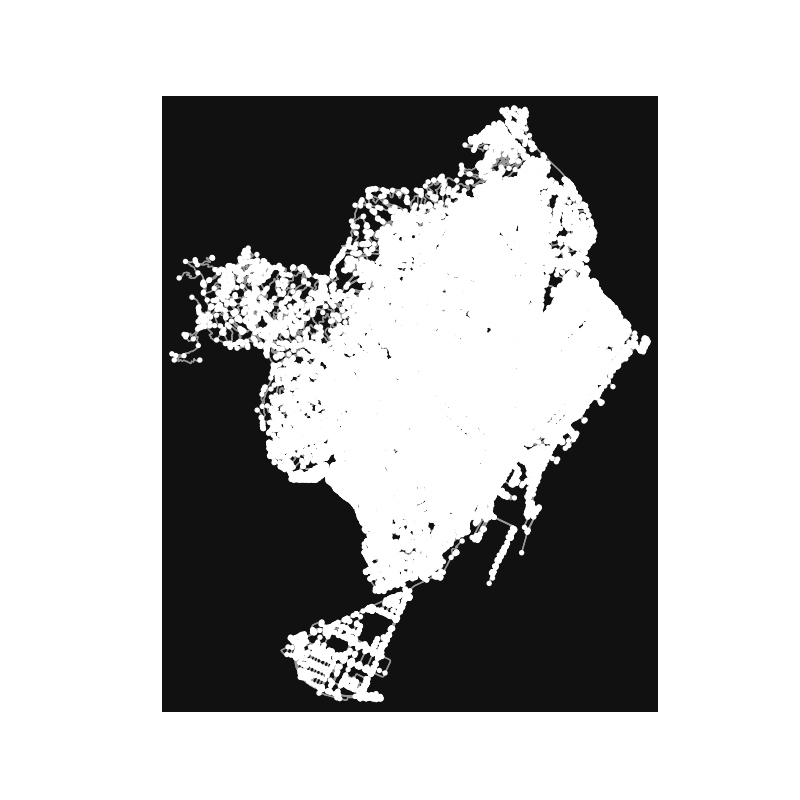

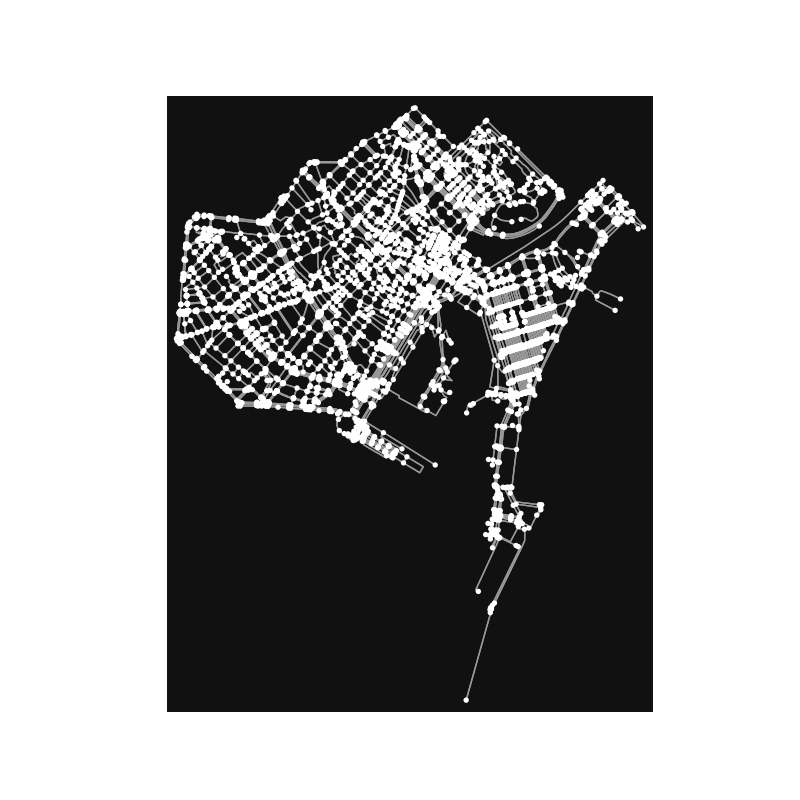

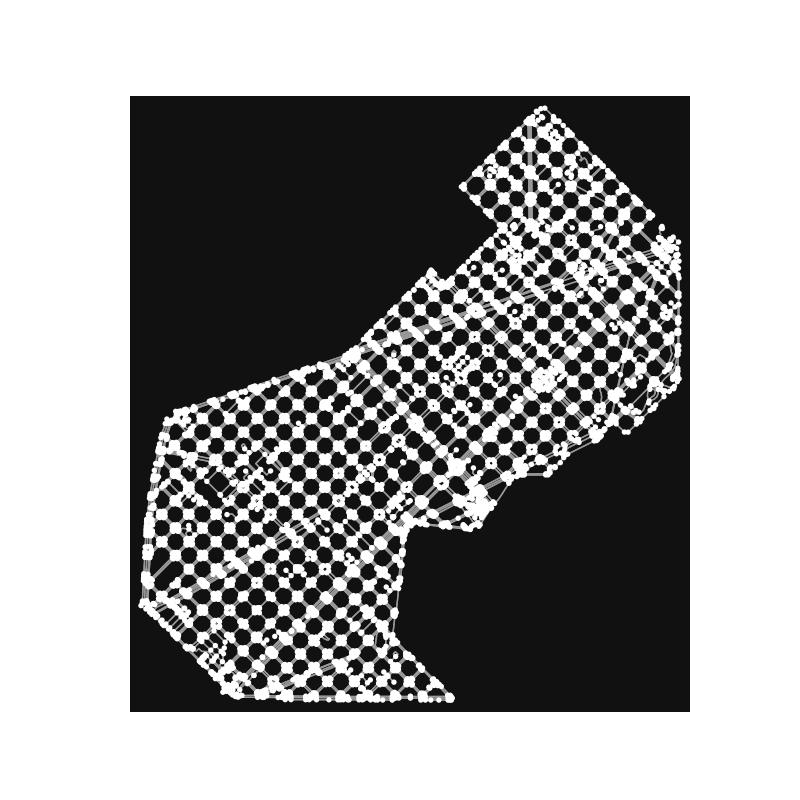

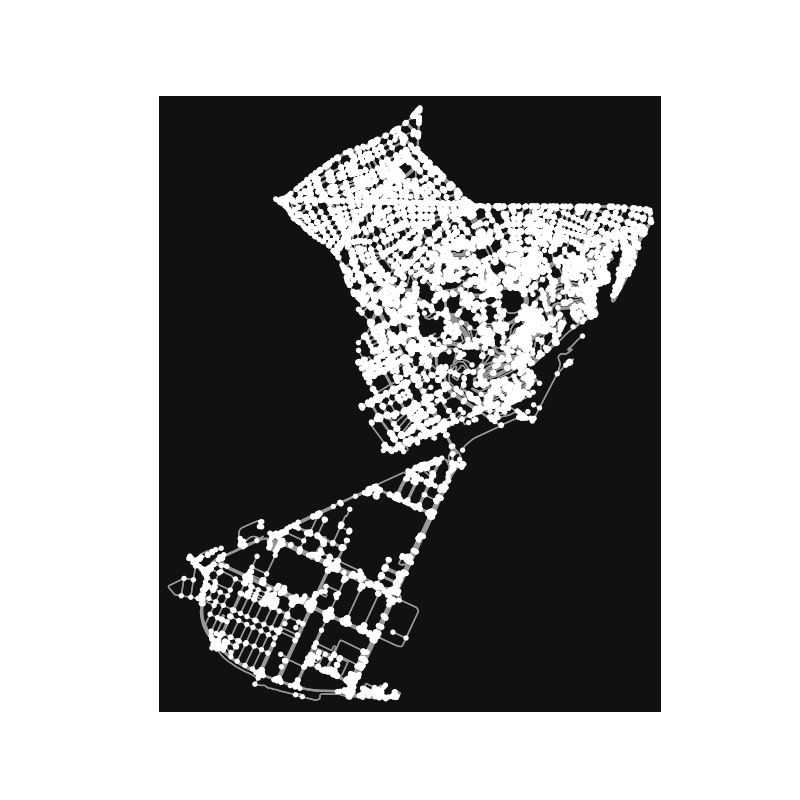

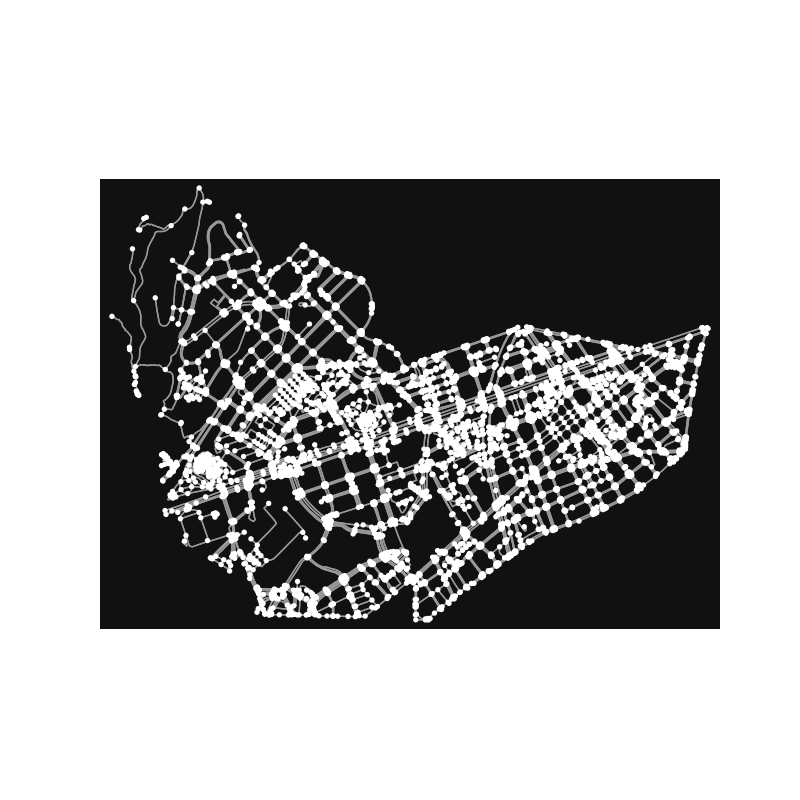

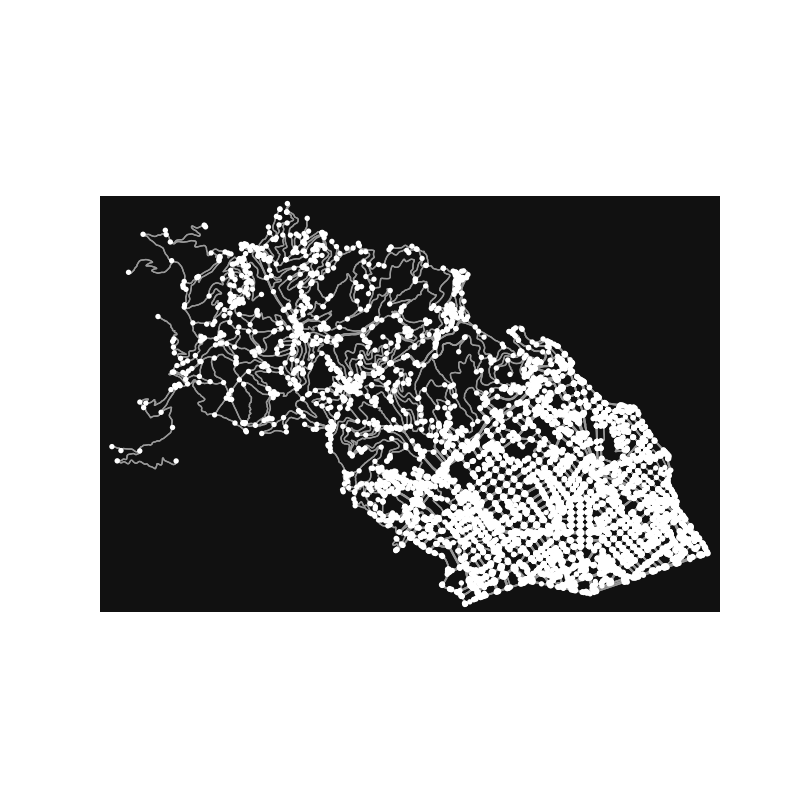

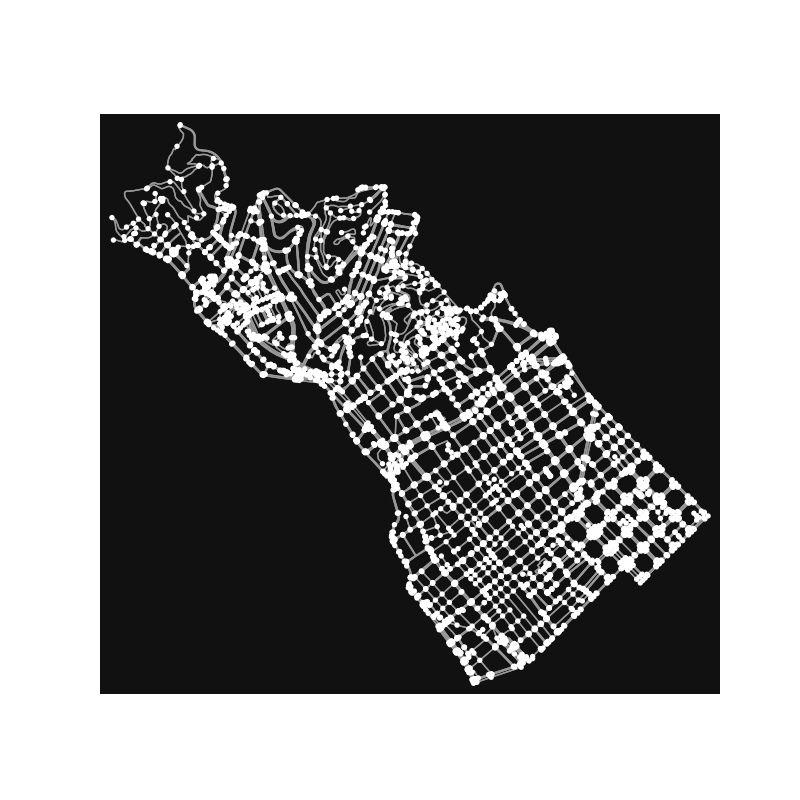

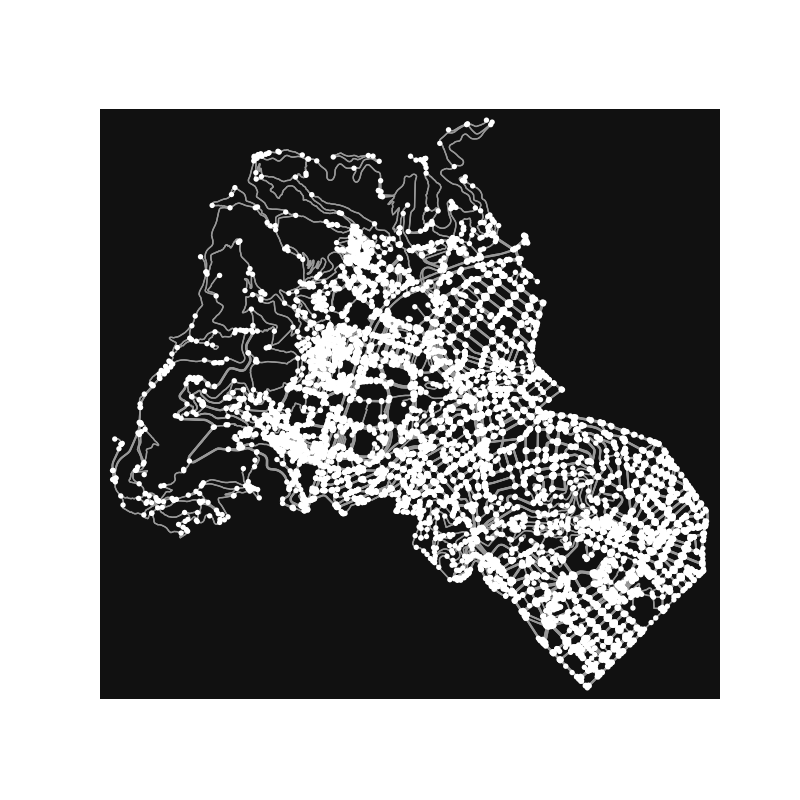

/home/pbretonn/miniconda3/envs/bikeit_env.yml/lib/python3.14/site-packages/osmnx/plot.py:1055: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=figsize, facecolor=bgcolor, frameon=False)


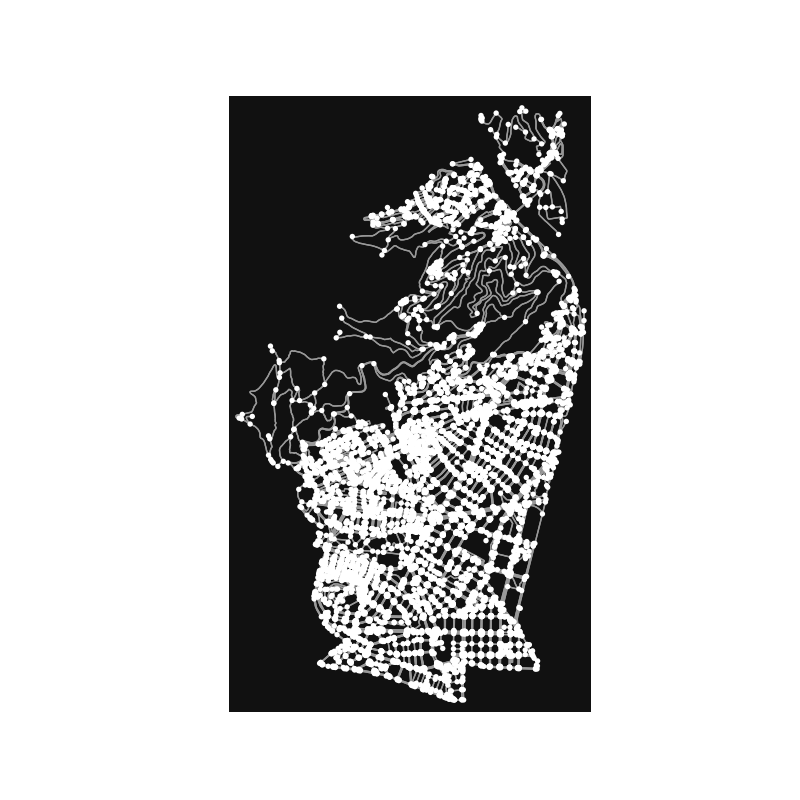

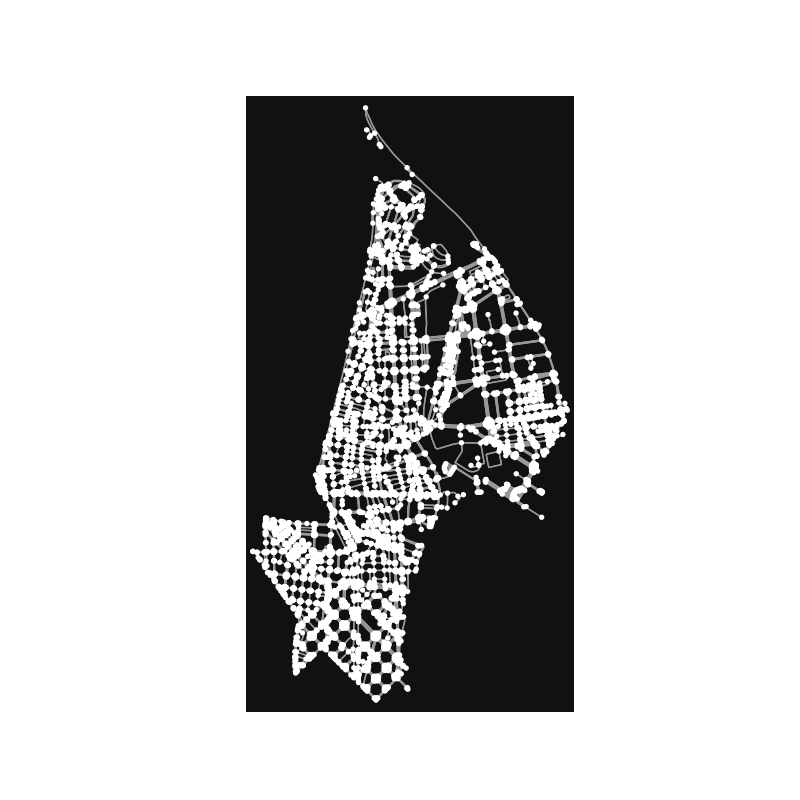

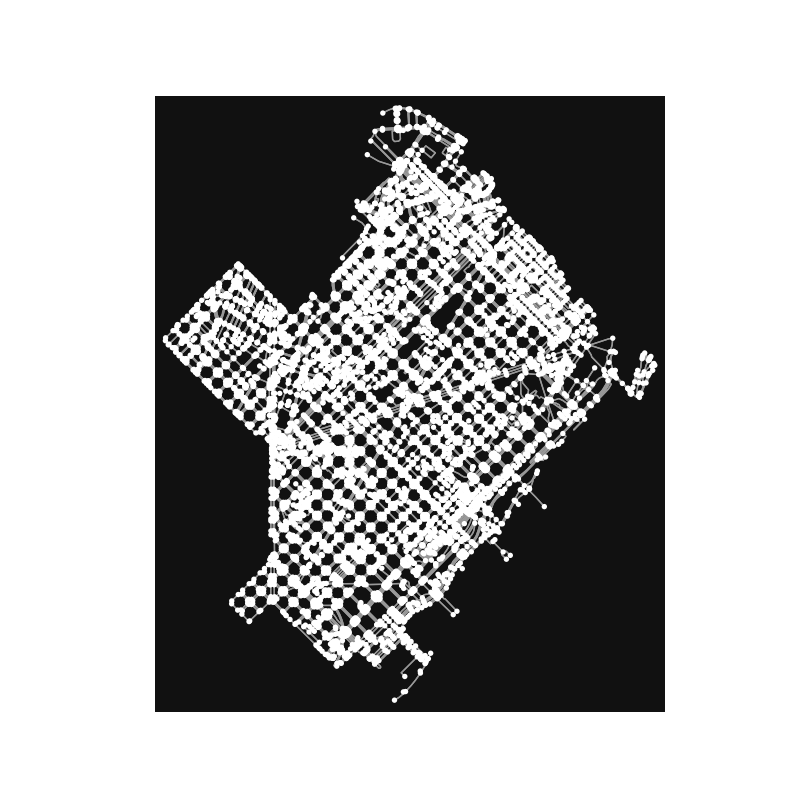

In [216]:
for district in list_districts:
    fig, ax = ox.plot.plot_graph(graph_dict[district])
    ax.set_title(district)

In [219]:
def get_graph_stats(graph):
    G_proj = ox.projection.project_graph(graph)
    nodes_proj = ox.convert.graph_to_gdfs(G_proj, edges=False)
    graph_area_m = nodes_proj.union_all().convex_hull.area
    graph_area_m = nodes_proj.union_all().convex_hull.area
    stats = ox.stats.basic_stats(G_proj, area=graph_area_m, clean_int_tol=15)
    return stats

In [225]:
#get_graph_stats(graph_dict["Gracia"])

In [228]:
stats = {}
for district in list_districts:
    stats[district]= get_graph_stats(graph_dict[district])
    print(district,stats[district])

Barcelona {'n': 72677, 'm': 231534, 'k_avg': 6.371589361145892, 'edge_length_total': 8040109.0954164, 'edge_length_avg': 34.7253927950815, 'streets_per_node_avg': 3.192069017708491, 'streets_per_node_counts': {0: 0, 1: 4889, 2: 1, 3: 44450, 4: 22983, 5: 314, 6: 35, 7: 3, 8: 2}, 'streets_per_node_proportions': {0: 0.0, 1: 0.06727025056070009, 2: 1.3759511262159968e-05, 3: 0.6116102756030106, 4: 0.31623484733822255, 5: 0.00432048653631823, 6: 0.0004815828941755989, 7: 4.12785337864799e-05, 8: 2.7519022524319936e-05}, 'intersection_count': 67788, 'street_length_total': 4020054.5477082, 'street_segment_count': 115767, 'street_length_avg': 34.7253927950815, 'circuity_avg': 1.0514610801855886, 'self_loop_proportion': 0.0007255953769208841, 'clean_intersection_count': 8784, 'node_density_km': 550.3128413636383, 'intersection_density_km': 513.2931586383356, 'edge_density_km': 60879.99341156392, 'street_density_km': 30439.99670578196, 'clean_intersection_density_km': 66.51276192658199}
Ciutat V

In [235]:
#example of access to stats of given district
total_street_length = stats["Barcelona"]["edge_length_total"]/1000.
total_street_length


8040.109095416399

In [233]:
#Example of access to coords of node of 1 district
node_id = list(graph_dict[district].nodes)[2]
graph_dict[district].nodes[node_id]

{'y': 41.3896468, 'x': 2.1914943, 'street_count': 3}

In [236]:
nth_edge = 5
print("Attributes for the first",nth_edge,"edges")
for i, (u, v, k, data) in enumerate(graph_dict[district].edges(keys=True, data=True)):
    print(f"Edge ({u}, {v}, {k}):")
    print(data["name"])
    for key, value in data.items():
        print(f"  - {key}: {value}")
    
    if i >= nth_edge:
        break

Attributes for the first 5 edges
Edge (30242971, 12945382589, 0):
Carrer de Buenaventura Muñoz
  - osmid: 1408659413
  - highway: secondary
  - lanes: 2
  - maxspeed: 30
  - name: Carrer de Buenaventura Muñoz
  - oneway: False
  - reversed: False
  - length: 5.623923962672086
  - geometry: LINESTRING (2.1868056 41.3931146, 2.1868329 41.3931383, 2.1868512 41.3931518)
Edge (30242973, 7309041609, 0):
Carrer de Llull
  - osmid: 546148428
  - highway: living_street
  - maxspeed: 10
  - name: Carrer de Llull
  - oneway: False
  - reversed: False
  - length: 26.480877708331832
  - geometry: LINESTRING (2.189113 41.3914648, 2.1889425 41.3913214, 2.1889005 41.3912879)
Edge (30242975, 7254110645, 0):
Carrer de Ramon Trias Fargas
  - osmid: 22689284
  - highway: tertiary
  - lanes: 2
  - maxspeed: 50
  - name: Carrer de Ramon Trias Fargas
  - oneway: False
  - reversed: True
  - length: 24.86924672957129
Edge (30242975, 7309041636, 0):
Carrer del Doctor Trueta
  - osmid: 4751884
  - highway: resi

In [238]:
edge_number = 6
nth_edge = None
edge_iterator = iter(graph_dict[district].edges(keys=True))

for _ in range(edge_number + 1):
        nth_edge = next(edge_iterator)
    
print("edge ", edge_number,nth_edge)


edge  6 (30242976, 71709940, 0)


In [242]:
coords_casa = [41.400971,2.160001] #from gmaps
coords_casa_hub = [41.4152636,2.1648925]

In [243]:
#test if lat,lon falls back on right street name
# 
u, v, k = ox.nearest_edges(
    G, 
    X=coords_casa[1], 
    Y=coords_casa[0]
)
print(u,v,k)
edge_attributes = G.get_edge_data(u, v, k)
edge_attributes.get('name')

30254379 30333334 0


'Carrer de la Fraternitat'

In [244]:
def get_edge_from_coords(graph, coords):
    u, v, k = ox.nearest_edges(
    graph, 
    X=coords[1], 
    Y=coords[0]
    )
    edge_attributes = graph.get_edge_data(u, v, k)
    if type(edge_attributes.get('name')) == str:  
        street_name = edge_attributes.get('name') #usually a string
    else:
        try:
            street_name = edge_attributes.get('name')[0] #edge with coords (41.4049091 2.1738864), (41.4052928 2.1755545) has Provenca and Marina
        except:
            street_name = "Unkwown" # edge from point 867 or 868 from PA has no street name
    #print(type(street_name),street_name)

    return((u,v,k),street_name)
    

In [252]:
def get_coords_gpx(user,n_segments=None):
    file = glob.glob(f'segments/{user}/*.gpx')[0] 
    gpx_file = open(file, 'r') 
    gpx = gpxpy.parse(gpx_file) 
    coords_gpx = []
    for track in gpx.tracks:
        for s, segment in enumerate(gpx.tracks[0].segments):
            if (user == 'hubert') & (s in [1, 6]):
                continue
            if n_segments and s >= n_segments:
                return coords_gpx
            for points in segment.points:
                coords_gpx.append((points.latitude,points.longitude))
    return coords_gpx
coords_gpx = get_coords_gpx("pa")
len(coords_gpx_pa)


13739

In [253]:
#adapted to multi-district until previous cell



#list_edges = [edge_casa,edge_hub]
list_edges = []
i=0
for lat, lon in coords_gpx_pa:
  #  if i < 100:
        print(i,"/",len(coords_gpx_pa))
        edge_and_name = get_edge_from_coords((lat,lon))
        #print("edge_and_name",edge_and_name)
        if edge_and_name not in list_edges:
            list_edges.append(edge_and_name)
       # list_edges[i]
        #if in new edge, add to the list of edges 
        #else:
        #    print("repeated")
        #shows the number of points per edges
        i=i+1
  #  else:
  #      break
list_edges

0 / 13739


TypeError: get_edge_from_coords() missing 1 required positional argument: 'coords'

In [180]:

highlighted_edges_set = {
    data[0] 
    for data in list_edges
}



edge_colors = []
for u, v, k in G.edges(keys=True):
    # The edge identifier is the tuple (u, v, k)
    edge_id = (u, v, k)
    
    if edge_id in highlighted_edges_set:
        # Assign red if the edge is in your list
        edge_colors.append("r")
     #   print("highligh",edge_id)
    else:
        # Assign black if the edge is NOT in your list
        edge_colors.append("k")
      #  print("normal",edge_id)

In [169]:
#type(list_edges)
#n=len(list_edges)
#list_edges[:][0]
#edge_colors

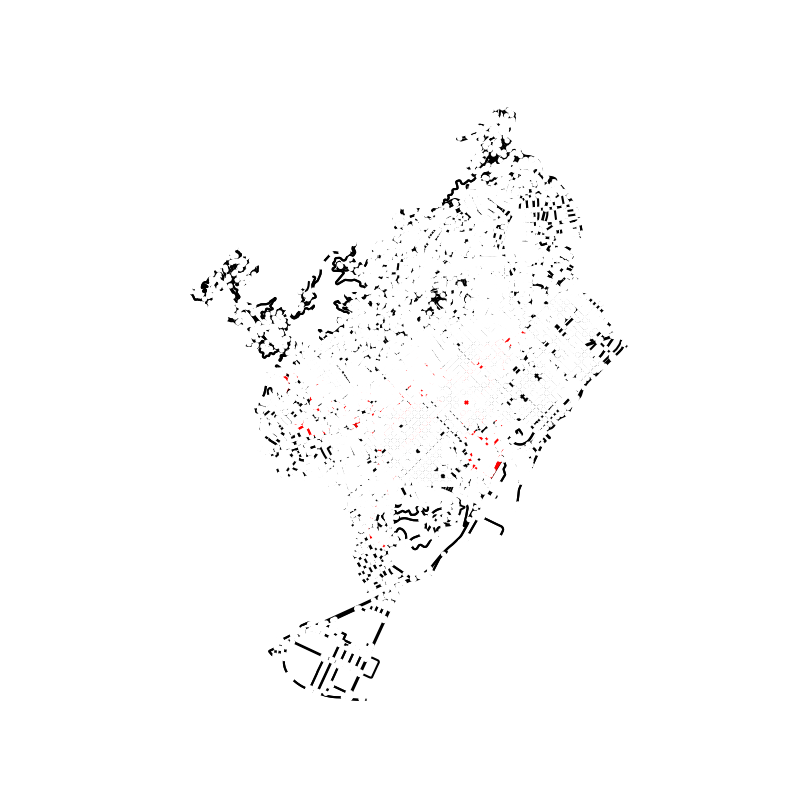

In [183]:
fig, ax = ox.plot.plot_graph(
    G,
    edge_color=edge_colors,
    edge_linewidth=1.5,
    show=False,
    close=False,
    bgcolor="w"
)

In [188]:
visited_street_names = [edge_data[1] for edge_data in list_edges]
len(set(visited_street_names))

369

In [181]:
%matplotlib widget

In [167]:
%matplotlib inline

In [191]:
def get_graph_street_names(graph):
    
    unique_street_names_from_G = set()

# Iterate over all edges in the graph, retrieving the attribute data for each edge
# We use keys=False because the u, v, k are not strictly needed for this task,
# only the data dictionary is.
    for _, _, data in graph.edges(data=True):
    # The street name is stored under the key 'name'
        name_entry = data.get('name')
    
    # Check if the 'name' attribute exists
        if name_entry is not None:
            
            if isinstance(name_entry, list):
                # If the value is a list (multiple names), add all individual names to the set
                for name in name_entry:
                    unique_street_names_from_G.add(name)
            elif isinstance(name_entry, str):
            # If the value is a single string, add it to the set
                unique_street_names_from_G.add(name_entry)

# The count of unique street names is the length of the final set
    count_unique_names_G = len(unique_street_names_from_G)
    print("Total number of streets",count_unique_names_G)
    return count_unique_names_G


In [207]:
get_graph_street_names(G)
get_graph_street_names(Gracia)
len(set(visited_street_names))/get_graph_street_names(G)*100


Total number of streets 2912
Total number of streets 318
Total number of streets 2912


12.671703296703296

In [209]:
street_percentage = len(set(visited_street_names))/get_graph_street_names(G)*100
df = pd.DataFrame({
    "number of mapped streets": [len(set(visited_street_names))],
    "total number of streets": [get_graph_street_names(G)],
    "percentage street": [street_percentage],
    "number of mapped segments ":[len(list_edges)],
    "total number of segments" : [stats["m"]], 
    "percentage segments": [len(list_edges)/stats["m"]*100],
    "mapped kms": ["-"],
    "total street length": [stats["edge_length_total"] /1000],
    "percentage km": ["-"]
})
df.style \
  .format(precision=3, thousands=".", decimal=",") \
  .format_index(str.upper, axis=1) \
  .relabel_index(["Barcelona"], axis=0)

Total number of streets 2912
Total number of streets 2912


,NUMBER OF MAPPED STREETS,TOTAL NUMBER OF STREETS,PERCENTAGE STREET,NUMBER OF MAPPED SEGMENTS,TOTAL NUMBER OF SEGMENTS,PERCENTAGE SEGMENTS,MAPPED KMS,TOTAL STREET LENGTH,PERCENTAGE KM
Barcelona,369,2.912,"12,672",1.247,16.493,"7,561",-,"1.671,639",-
